## 2. Compresión de los Datos


### Análisis de Datos Exploratorio

### Importaciones y versionamiento

In [1]:
#!pip install -q pandas
#!pip install -q numpy
#!pip install -q matplotlib
#!pip install -q seaborn
#!pip install -q statsmodels
#!pip install -q scikit-learn
#!pip install -q xgboost
#!pip install -q lightgbm


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import xgboost as xgb
import lightgbm as lgb
import scipy.stats as ss

import sys
sys.path.append('../')
from src.utils.eda_plots import grafico_distribucion
from scipy.stats import chi2_contingency
from src.features.features_engineering import feature_engineering



print("Pandas:", pd.__version__)
print("Numpy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Seaborn:", sns.__version__)

Pandas: 2.1.4
Numpy: 1.26.4
Matplotlib: 3.7.5
Seaborn: 0.13.2


## Carga de datos

In [2]:
df = pd.read_csv("../data/raw/Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")
df.head()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,3270,52,Self-Employed,12167848,850,50000,Fashion,9,0,0,0,449,USA,5/18/2023,410919005562857,0,Low Risk
1,10250,56,Self-Employed,14576712,850,50000,Fashion,12,0,0,0,492,Canada,9/27/2024,343012882466224,0,Low Risk
2,6702,56,Self-Employed,10739282,850,50000,Sports,6,0,0,0,698,USA,1/4/2023,465580473629428,0,Low Risk
3,8421,48,Self-Employed,11557268,850,50000,Electronics,9,0,0,0,537,Australia,10/19/2024,43262819552164,0,Low Risk
4,7787,50,Self-Employed,10256821,850,50000,Beauty,6,0,0,0,973,Canada,9/9/2024,487480477625572,0,Low Risk


## Exploración Básica

In [3]:
df.shape

(9528, 17)

Como primer vistazo, la base de datos contiene la información sobre los clientes que adquirieron producto mediante BNPL; hay información como la edad, ocupación, sus ingresos mensuales, puntaje crediticio, el monto de la compra, categoría, etc.

### Conteo de nulos

In [4]:
df.isnull().sum()

user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64

Como podemos observar, nuestra base de datos no tiene ningún valor nulo; no es necesario hacer métodos de imputación, eliminación, etc.

In [5]:
(df == "?").sum()

user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64

Tambien, podemos observar que no hay datos con '?' representando que se conocen todos los valores

In [6]:
df.duplicated().sum()

0

Para saber si habían datos o registros duplicados se usó la función df.duplicated.sum(), la
cual arroja la cantidad de datos duplicados (0) . No se encuentra ningún duplicado para el
análisis

### Tipos de variables y Número de registros

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9528 entries, 0 to 9527
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   user_id               9528 non-null   int64 
 1   age                   9528 non-null   int64 
 2   employment_type       9528 non-null   object
 3   monthly_income        9528 non-null   int64 
 4   credit_score          9528 non-null   int64 
 5   purchase_amount       9528 non-null   int64 
 6   product_category      9528 non-null   object
 7   bnpl_installments     9528 non-null   int64 
 8   repayment_delay_days  9528 non-null   int64 
 9   missed_payments       9528 non-null   int64 
 10  default_flag          9528 non-null   int64 
 11  app_usage_frequency   9528 non-null   int64 
 12  location              9528 non-null   object
 13  transaction_date      9528 non-null   object
 14  debt_to_income_ratio  9528 non-null   int64 
 15  risk_score            9528 non-null   

De esta manera podemos identificar que nuestra base de datos tiene 10345 registros y 17 columnas

### Diccionario de variables

| Columna                | Tipo     | Descripción |
|------------------------|----------|-------------|
| user_id               | int64    | Identificador único del usuario |
| age                   | int64    | Edad del usuario (18–59 años) |
| employment_type       | object   | Tipo de empleo: Asalariado / Independiente / Estudiante / Desempleado |
| monthly_income        | float64  | Ingreso mensual en USD |
| credit_score          | int64    | Puntaje de crédito estándar (300–850) |
| purchase_amount       | float64  | Valor de la compra en modalidad BNPL (USD) |
| product_category      | object   | Categoría del producto: Electrónica, Moda, Deportes, Hogar, Belleza |
| bnpl_installments     | int64    | Número de cuotas de pago (3, 6, 9, 12) |
| repayment_delay_days  | int64    | Días de retraso en el pago (0–33) |
| missed_payments       | int64    | Número total de pagos perdidos (0–7) |
| default_flag          | int64    | Variable objetivo: 1 = Incumplimiento (default), 0 = Pago correcto |
| app_usage_frequency   | float64  | Frecuencia de uso de la aplicación (aperturas por semana) |
| location              | object   | País del usuario (USA, India, UK, Alemania, Canadá, Australia) |
| transaction_date      | object   | Fecha de la transacción (YYYY-MM-DD) |
| debt_to_income_ratio  | float64  | Relación deuda-ingreso (deuda mensual / ingreso mensual) |
| risk_score            | float64  | Puntaje de riesgo compuesto (0–398), valores altos indican mayor riesgo |
| customer_segment      | object   | Segmento de riesgo del cliente: Bajo, Medio, Alto |




### Clasificación

- **Variable objetivo (1)**
  - default_flag  


- **Variables numéricas (11)**
  - user_id  
  - age  
  - monthly_income  
  - credit_score  
  - purchase_amount  
  - bnpl_installments  
  - repayment_delay_days  
  - missed_payments  
  - app_usage_frequency  
  - debt_to_income_ratio  
  - risk_score  


- **Variables categóricas (4)**
  - employment_type  
  - product_category  
  - location  
  - customer_segment  


- **Variables de tipo fecha (1)**
  - transaction_date  


Luego de realizar el análisis inicial del dataset, se observa que la variable transaction_date aparece con tipo de dato object. Sin embargo, esta variable corresponde a una fecha, por lo que debería tratarse como una variable de tipo temporal.

In [8]:
df.nunique()

user_id                 9528
age                       42
employment_type            4
monthly_income          9172
credit_score             531
purchase_amount         3832
product_category           5
bnpl_installments          4
repayment_delay_days      33
missed_payments            8
default_flag               2
app_usage_frequency      901
location                   6
transaction_date         365
debt_to_income_ratio    9511
risk_score               748
customer_segment           3
dtype: int64

In [9]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

Aquí hicimos la transformación de la variable transaction_date, pero será una variable que eliminaremos en la preparación de los datos ya que no tiene relevancia para los modelos predictivos. Actúa más como un identificador temporal que ayuda a complementar el análisis exploratorio (por ejemplo, para detectar patrones estacionales o tendencias temporales que pueden ser mostrados en el Dashboard creado), pues estra variable no llega a aportar un predictivo.

### Análisis de Target

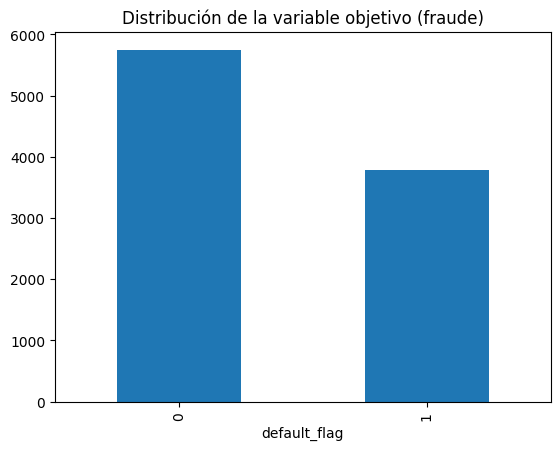

In [10]:
df['default_flag'].value_counts().plot(kind='bar')
plt.title("Distribución de la variable objetivo (fraude)")
plt.show()

Como podemos observar en la variable de default_flag. La mayoria de los casos son de cumplimiento de los pagos que fueron mas de 6000 personas y las personas que incumplieron con los pagos son 4000 alrededormente. Hay un pequeño desbalance entre clases. De esta manera, es ideal centrarse en las personas que no pagaron, usando las metricas como recall y F1-score reduciendo los falsos negativos. Siempre y cuando no generemos tantos falsos positivos

### Análisis Univariado

Filtrar solo las columnas numéricas

In [11]:
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns
numerical_vars

Index(['user_id', 'age', 'monthly_income', 'credit_score', 'purchase_amount',
       'bnpl_installments', 'repayment_delay_days', 'missed_payments',
       'default_flag', 'app_usage_frequency', 'debt_to_income_ratio',
       'risk_score'],
      dtype='object')

In [12]:
# Se excluyen variables que no aportan información analítica directa
columnas_a_excluir = ['user_id','default_flag','missed_payments','bnpl_installments']

variables_numericas_validas = [
    col for col in numerical_vars 
    if col not in columnas_a_excluir
]

variables_numericas_validas

['age',
 'monthly_income',
 'credit_score',
 'purchase_amount',
 'repayment_delay_days',
 'app_usage_frequency',
 'debt_to_income_ratio',
 'risk_score']

Vamos a eliminar la variable de user_id ya que es un identificador y no representa un poder analitico.

Las demas variables, se hara un analisis una por una ya que no tienen una distribucion como tal, son mas repetitivas o categoricas

In [13]:
#Estas son las variables que dejaremos para los siguientes analisis

variables_numericas_validas2 =[col for col in numerical_vars]

In [14]:
df.describe()

,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,transaction_date,debt_to_income_ratio,risk_score
count,9528.000000,9528.000000,9.528000e+03,9528.000000,9528.000000,9528.000000,9528.000000,9528.000000,9528.000000,9528.000000,9528,9.528000e+03,9528.000000
mean,5172.217569,38.488875,3.102250e+06,443.662259,126615.149664,7.479849,8.808669,1.025609,0.396725,505.244752,2023-12-31 09:34:36.574307328,1.584764e+15,2006.646096
min,1.000000,18.000000,5.000000e+04,300.000000,1000.000000,3.000000,0.000000,0.000000,0.000000,10.000000,2023-01-01 00:00:00,2.000000e+00,0.000000
25%,2599.750000,28.000000,9.576048e+05,330.000000,50000.000000,3.000000,2.000000,0.000000,0.000000,256.000000,2023-03-30 00:00:00,6.387170e+14,1580.000000
50%,5158.500000,39.000000,1.859956e+06,395.000000,50000.000000,9.000000,9.000000,1.000000,0.000000,507.000000,2024-07-01 00:00:00,1.123025e+15,2056.000000
75%,7760.250000,49.000000,5.121084e+06,540.000000,190884.500000,9.000000,14.000000,2.000000,1.000000,755.000000,2024-10-01 00:00:00,2.491369e+15,2501.000000
max,10345.000000,59.000000,1.457671e+07,850.000000,499785.000000,12.000000,33.000000,7.000000,1.000000,999.000000,2024-12-31 00:00:00,7.230235e+15,3980.000000
std,2981.725680,12.140577,2.746621e+06,135.789878,130614.581944,3.362375,6.754603,0.995305,0.489244,287.831452,NaN,1.286311e+15,667.265980


In [15]:
variables_con_cero = ['repayment_delay_days','missed_payments','default_flag','risk_score']

for var in variables_con_cero:
    conteo_ceros = (df[var] == 0).sum()
    
    if conteo_ceros > 0:
        print(f"La variable {var} tiene {conteo_ceros} valores igual a 0")
    else:
        print(f"La variable {var} no tiene valores en 0")

La variable repayment_delay_days tiene 1084 valores igual a 0
La variable missed_payments tiene 3335 valores igual a 0
La variable default_flag tiene 5748 valores igual a 0
La variable risk_score tiene 9 valores igual a 0


- repayment_delay_days: Muestra que tiene 1219 valores igual a 0 lo que significa lso clientes que no han presentado retrasos en sus pagos.
- missed_payments: Indica que 3704 clientes no han incumplido con ningun pago de cuotas.

- default_flag: Esta es nuestra target, donde podemos observar que 6305 clientes han pagado correctamente.

- risk_score: Hay 9 clientes con un riesgo 0 en cambio todos los demas si tienen algun riesgo

#### Distribucion de variables numericas Discretas

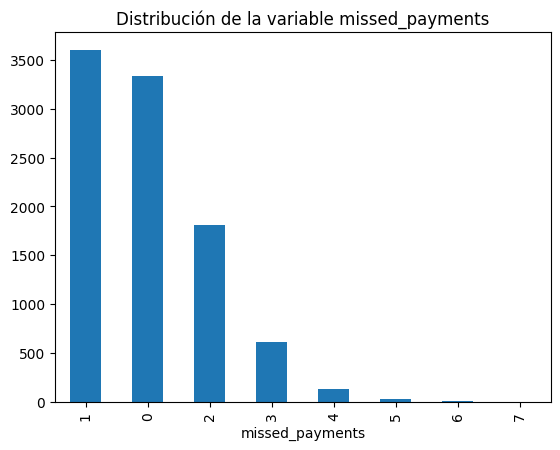

In [16]:
df['missed_payments'].value_counts().plot(kind='bar')
plt.title("Distribución de la variable missed_payments")
plt.show()

Gracias a la gráfica podemos observar que presenta una distribución sesgada hacia la derecha. Donde la gran mayoría de los usuarios registran cero pagos perdidos y son muy pocos los que dejan 4 o más días sin pagar su crédito De manera que nos ayuda a perfilar qué clientes pueden tener un bajo o alto riesgo para la compañía.

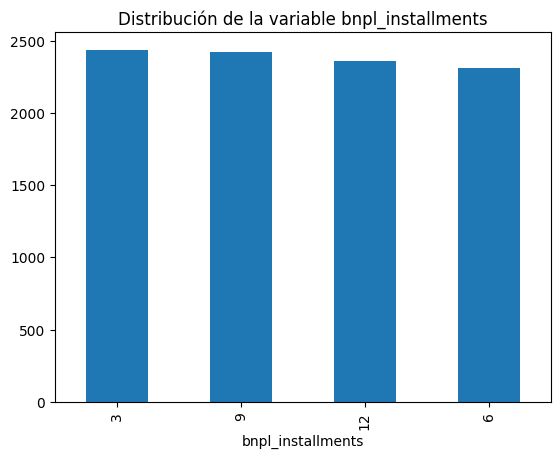

In [17]:
df['bnpl_installments'].value_counts().plot(kind='bar')
plt.title("Distribución de la variable bnpl_installments")
plt.show()

Aqui podemos observar que los usuarios utilizan principalmente 3,9,12,6 cuotas para las compras que hacen. Donde 3 y 9 cuotas son las preferidas por los clientes. De igual forma es algo muy equitativo

#### Distribuciones de las variables numericas continuas

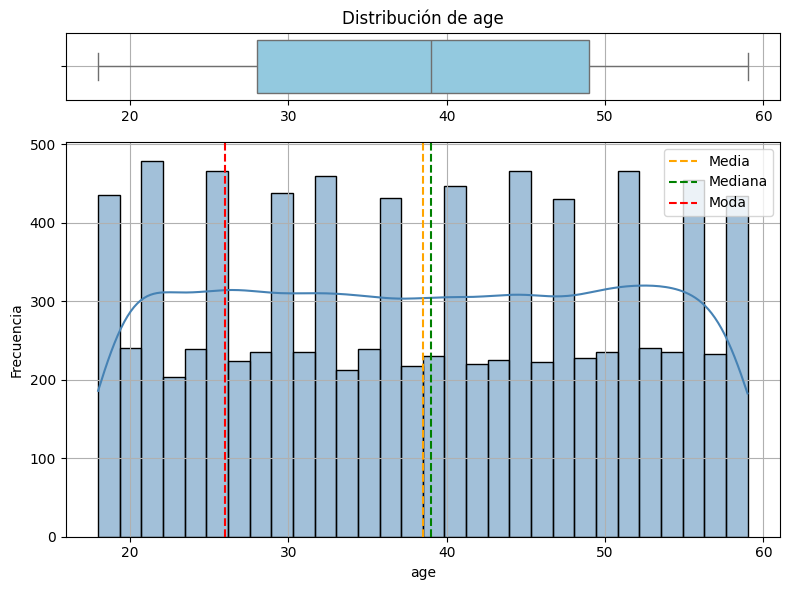

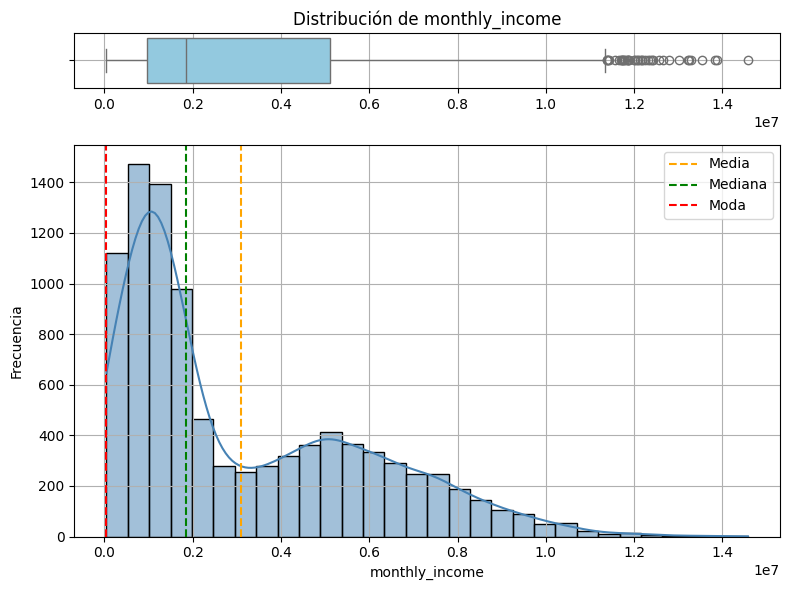

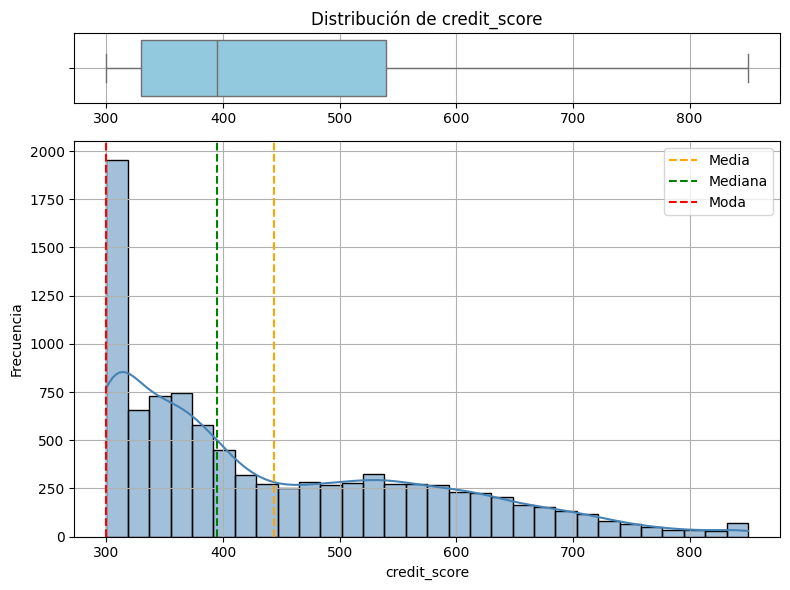

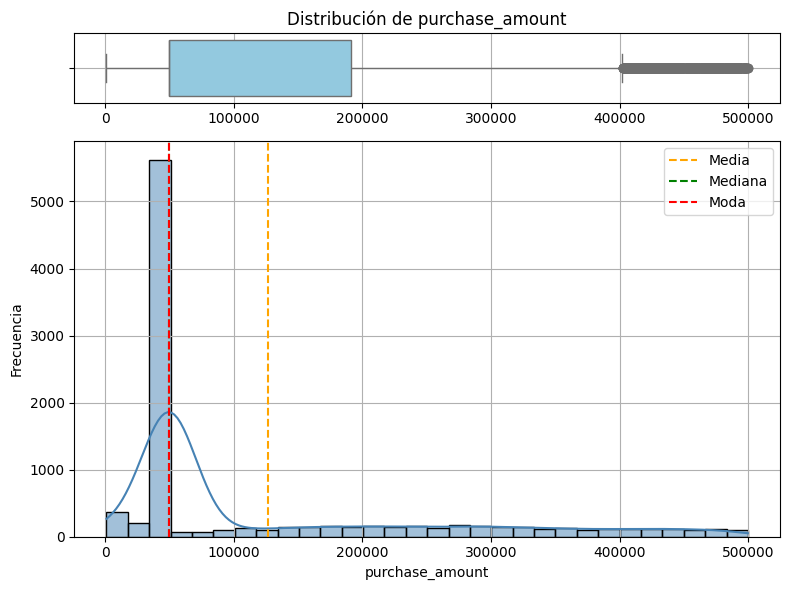

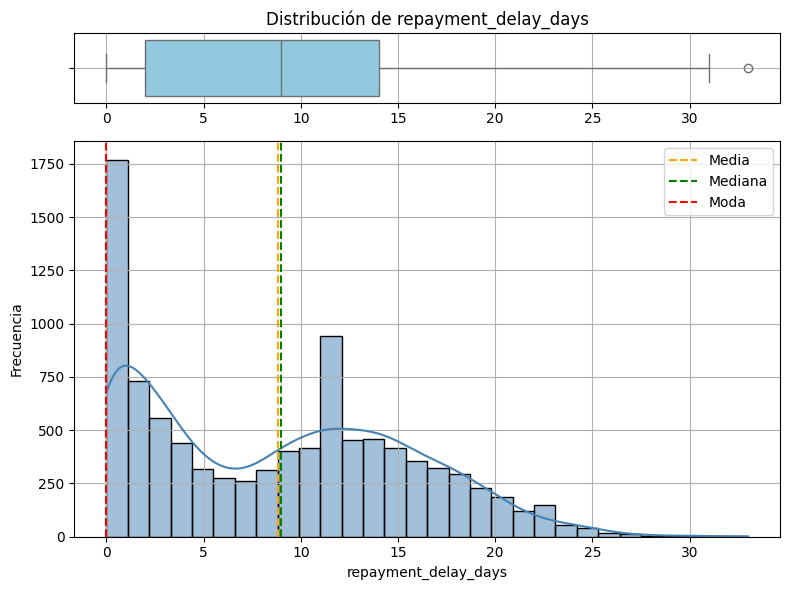

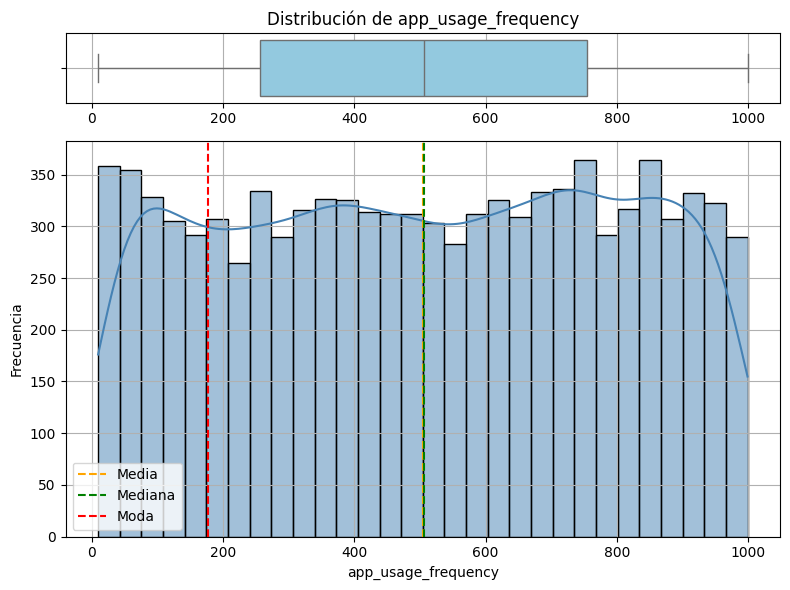

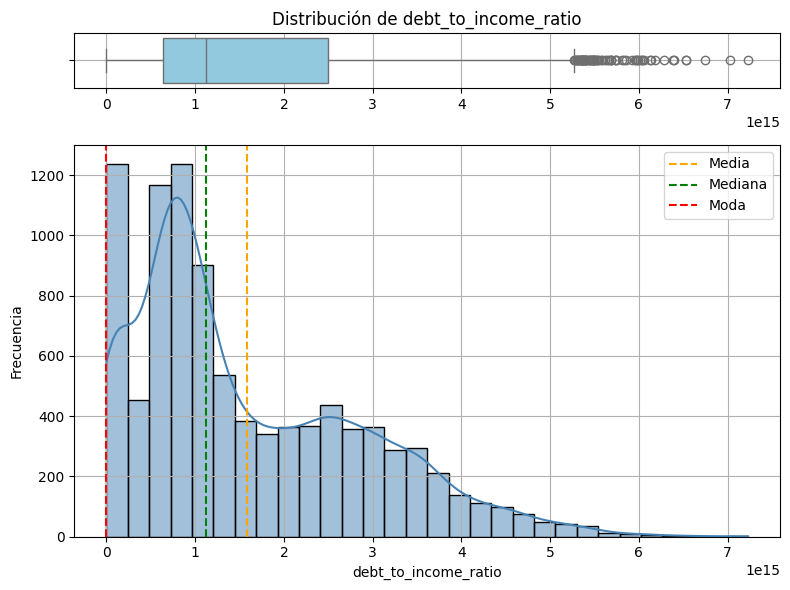

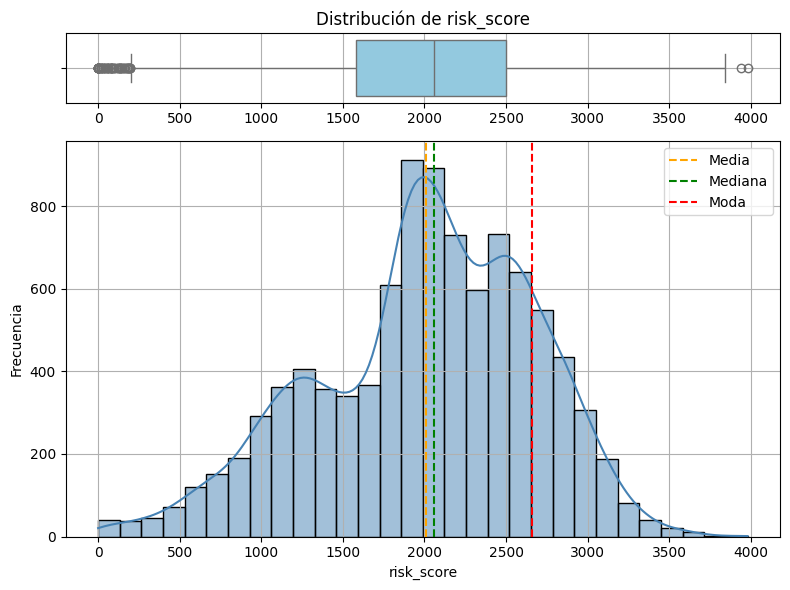

In [18]:
for var in variables_numericas_validas:
    grafico_distribucion(df, var)


- La variable de distribución de age no presenta una distribución notoria; tiene múltiples picos en 18, 22, 30, 33, 40, etc. Donde se muestra una gran cantidad de personas con esta edad. No se muestran datos atípicos y es posible poder categorizarla por rangos de edad, como joven, adulto, adulto, etc. Y ver si beneficia al modelo.

- la variable monthly_income muestra una distribución extremadamente sesgada a la derecha, con una gran concentración de ingresos por debajo de 20,000 USD y una cola muy larga que llega hasta 140,000 USD. Con una gran cantidad de outsiders Podría ser ideal una transformación logarítmica para que tenga una distribución más normal.

- La variable credit_score muestra una distribución sesgada a la derecha. Donde se muestran puntajes crediticios menores a 400 en la mayoría de las personas y una cola que llega hasta más de 800 de puntaje.

- La variable de purchase_amount tiene una distribución extremadamente sesgada a la izquierda, donde la mayoría de las compras son de productos por 5000 USD.

- La variable repayment_delay_days presenta una distribución con sesgo positivo muy marcado, donde la mayoría de los registros tienen 0 días de retraso (moda en 0) y una cola larga que llega hasta 30 días.                  

- La variable default_flag es binaria (0 y 1). La gráfica muestra una frecuencia mucho mayor para 0 (pago correcto), que esta es nuestra variable target.

-  La variable app_usage_frequency. Tiene una distribución parecida a la variable age. Ya que los usuarios suelen utilizar o abrir la app desde 1 hasta 10 veces. Su distribucion relativamente simétrica. No se observan outliers extremos. Esta variable puede usarse tal cual o estandarizarse.                

- La variable debt_to_income_ratio presenta una distribución con sesgo positivo, concentrada en valores bajos y una cola que llega hasta 0.7. La media es mayor que la mediana, indicando valores extremos altos que elevan el promedio. Es recomendable aplicar una transformación logarítmica  para ver cómo se comporta; categorizar podría ser una opción.

- Por último, la variable risk_score tiene una distribución aproximadamente normal con ligero sesgo a la derecha, con el pico entre 150 y 250 y una cola que se extiende hasta cerca de 400. No se observan outliers severos. Esta variable no requiere transformación.

#### Prueba para ver variables representativas con distribuciones en raíz y logaritmo.

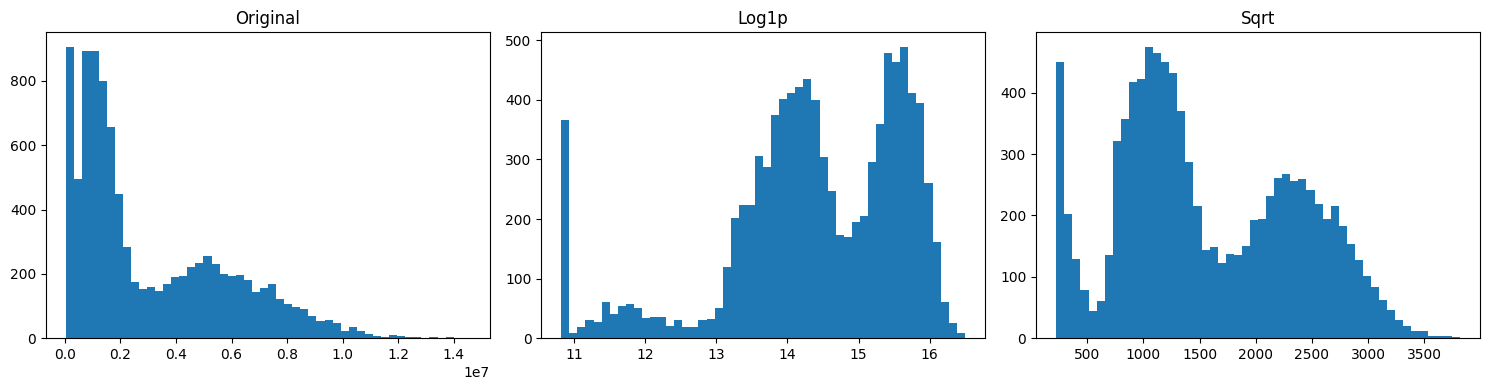

In [19]:
plt.figure(figsize=(15, 4))

# Evitar valores negativos o NaN
data = df['monthly_income'].dropna()

plt.subplot(1, 3, 1)
plt.hist(data, bins=50)
plt.title("Original")

plt.subplot(1, 3, 2)
plt.hist(np.log1p(data), bins=50)
plt.title("Log1p")

plt.subplot(1, 3, 3)
plt.hist(np.sqrt(data), bins=50)
plt.title("Sqrt")

plt.tight_layout()
plt.show()

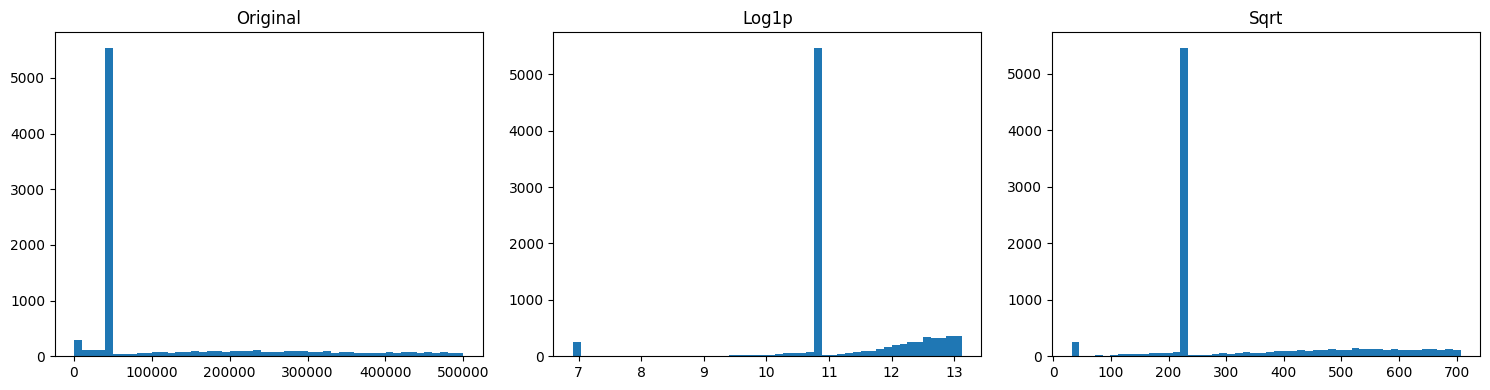

In [20]:
plt.figure(figsize=(15, 4))

data = df['purchase_amount'].replace([np.inf, -np.inf], np.nan).dropna()

data = data[data >= 0]

plt.subplot(1, 3, 1)
plt.hist(data, bins=50)
plt.title("Original")

plt.subplot(1, 3, 2)
plt.hist(np.log1p(data), bins=50)
plt.title("Log1p")

plt.subplot(1, 3, 3)
plt.hist(np.sqrt(data), bins=50)
plt.title("Sqrt")

plt.tight_layout()
plt.show()

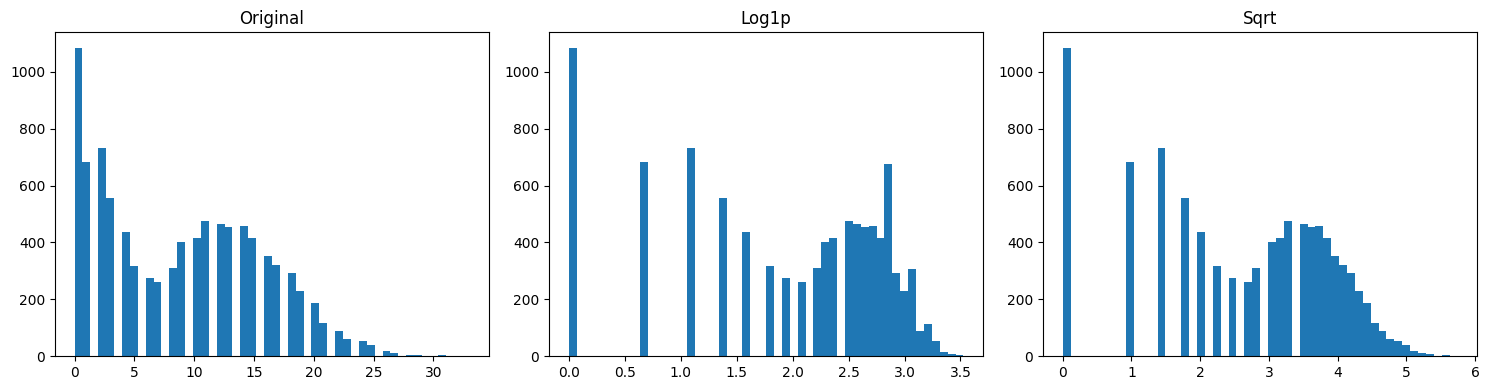

In [21]:

plt.figure(figsize=(15, 4))

data = df['repayment_delay_days'].replace([np.inf, -np.inf], np.nan).dropna()

data_log = data[data >= 0]

plt.subplot(1, 3, 1)
plt.hist(data, bins=50)
plt.title("Original")

plt.subplot(1, 3, 2)
plt.hist(np.log1p(data_log), bins=50)
plt.title("Log1p")

plt.subplot(1, 3, 3)
plt.hist(np.sqrt(data_log), bins=50)
plt.title("Sqrt")

plt.tight_layout()
plt.show()

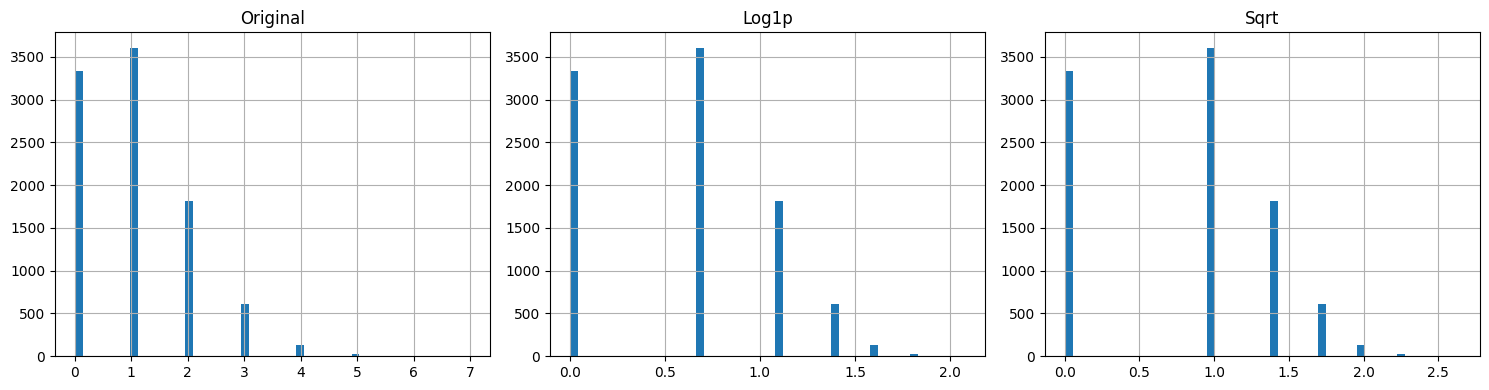

In [22]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
df['missed_payments'].hist(bins=50)
plt.title("Original")

plt.subplot(1, 3, 2)
np.log1p(df['missed_payments']).hist(bins=50)
plt.title("Log1p")

plt.subplot(1, 3, 3)
np.sqrt(df['missed_payments']).hist(bins=50)
plt.title("Sqrt")

plt.tight_layout()

Text(0.5, 1.0, 'Sqrt')

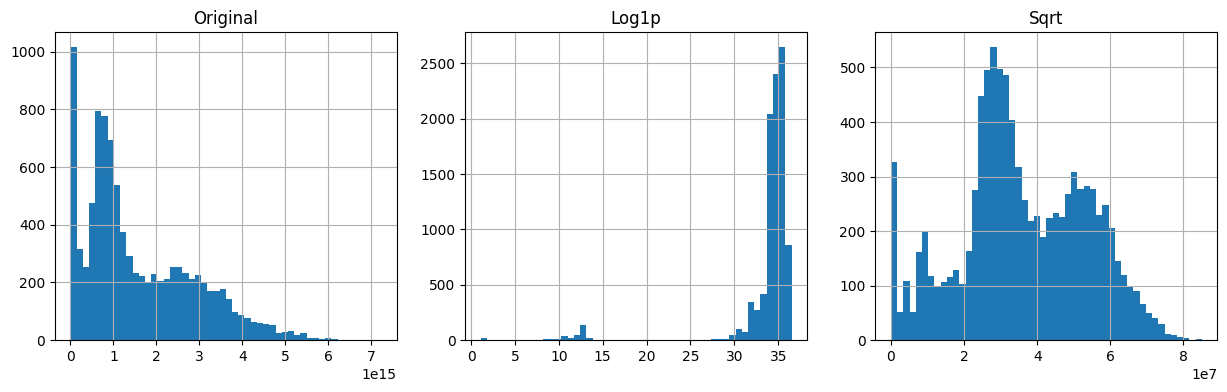

In [23]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
df['debt_to_income_ratio'].hist(bins=50)
plt.title("Original")

plt.subplot(1, 3, 2)
np.log1p(df['debt_to_income_ratio']).hist(bins=50)
plt.title("Log1p")

plt.subplot(1, 3, 3)
np.sqrt(df['debt_to_income_ratio']).hist(bins=50)
plt.title("Sqrt")

Como podemos observar luego de ver las variables convertidas, no se muestra un gran cambio en las distribuciones, de manera que no tiene relevancia hacer el proceso de normalización o raíz cuadrada para el entrenamiento del modelo. Para el proyecto, como recomendación del docente, se trabajará tal cual como está.

#### Distribucion de las variables categoricas

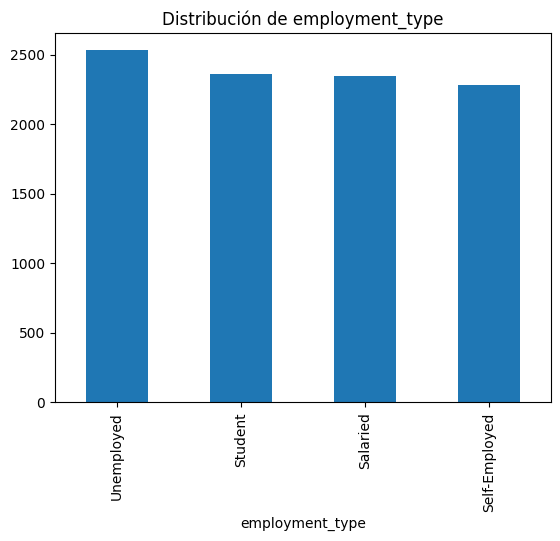

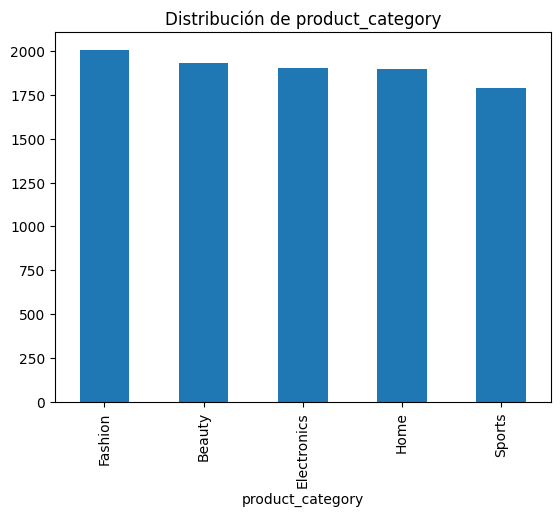

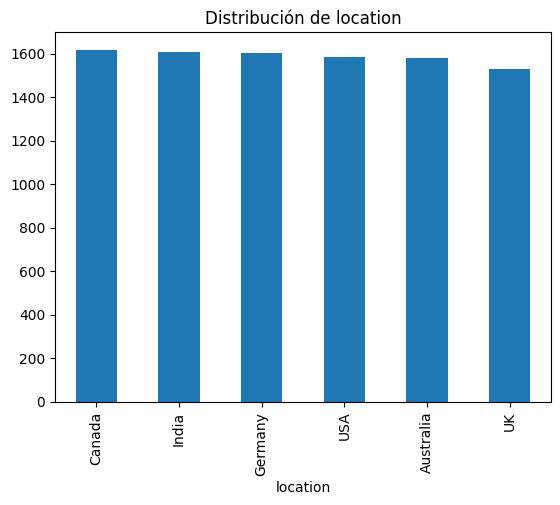

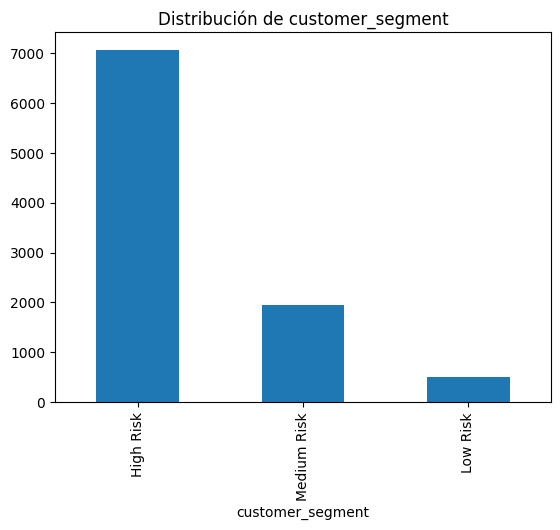

In [24]:
cat_cols = [
    'employment_type',
    'product_category',
    'location',
    'customer_segment'
]

for col in cat_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribución de {col}")
    plt.show()

Luego de ver las distribuciones de las variables categóricas, podemos ver que en employment_type se muestra muy equilibrado en los cuatro tipos que hay (Salaried, Unemployed, Self-Employed y Student), mostrando una frecuencia entre 2550 y 2650 aproximadamente en cada una.

En la variable product_category podemos observar que la predominante es Fashion, con aproximadamente 2200, seguida muy de cerca por Electronics, Beauty y Home (2050-2100 aprox.), y Sports es la menos frecuente, con 1980. De igual forma, también es una variable bastante equilibrada.

Por otro lado, en la variable location parece ser la más balanceada de todas; con los seis países (Germany, Canada, USA, India, Australia y UK) se está concentrando entre 1650 y 1750 registros cada uno, mostrando una excelente cobertura geográfica sin sesgos tan notorios.

Por último, la variable customer_segment revela un gran desequilibrio. Podemos decir que por lo menos el 75 % de los clientes se encuentran en High Risk 7500, frente a 2200 en Medium Risk y apenas 650 en Low Risk. De esta forma podríamos concluir que los clientes de BNPL están centrados en perfiles de mayor riesgo. ¿Dónde podrían ser las personas que mayormente incumplen con los pagos?

### Analisis Multivariado

In [25]:
cols_categoricas = ['employment_type','product_category','location','customer_segment']

alertas = []

for col in cols_categoricas:
    print(f"\n Relación {col} vs default:")
    
    ct = pd.crosstab(df[col], df['default_flag'], normalize='index')
    display(ct)
    
    # Asegurar que existan ambas columnas (0 y 1)
    if 0 in ct.columns and 1 in ct.columns:
        ct['diff'] = abs(ct[1] - ct[0])
        max_diff = ct['diff'].max()
    else:
        max_diff = 0
    
    alertas.append((col, max_diff))

    # Alerta si hay diferencia fuerte
    if max_diff > 0.3:
        print(f"Variable {col} tiene una categoría con alta diferencia de default: {max_diff:.2f}")

# Ordenar variables más relevantes
alertas = sorted(alertas, key=lambda x: x[1], reverse=True)

print("\nVariables categóricas más relevantes:")
print(alertas)


 Relación employment_type vs default:


default_flag,0,1
employment_type,,
Salaried,0.665106,0.334894
Self-Employed,0.731376,0.268624
Student,0.513113,0.486887
Unemployed,0.514613,0.485387


Variable employment_type tiene una categoría con alta diferencia de default: 0.46

 Relación product_category vs default:


default_flag,0,1
product_category,,
Beauty,0.617098,0.382902
Electronics,0.604724,0.395276
Fashion,0.582253,0.417747
Home,0.602848,0.397152
Sports,0.610832,0.389168



 Relación location vs default:


default_flag,0,1
location,,
Australia,0.596458,0.403542
Canada,0.603832,0.396168
Germany,0.593146,0.406854
India,0.614046,0.385954
UK,0.602614,0.397386
USA,0.609464,0.390536



 Relación customer_segment vs default:


default_flag,0,1
customer_segment,,
High Risk,0.503046,0.496954
Low Risk,0.931641,0.068359
Medium Risk,0.878896,0.121104


Variable customer_segment tiene una categoría con alta diferencia de default: 0.86

Variables categóricas más relevantes:
[('customer_segment', 0.86328125), ('employment_type', 0.46275197195442597), ('product_category', 0.23419689119170983), ('location', 0.22809198259788688)]


1. Self-employed puede ser muy predictiva
2. Low y medium risk son muy predictivas

#### Análisis de fuerza de relación - Cramer

In [26]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))

cat_cols = ['employment_type', 'product_category', 'location', 'customer_segment']

for col in cat_cols:
    v = cramers_v(df[col], df['default_flag'])
    print(f"{col}: {v:.3f}")

employment_type: 0.194
product_category: 0.024
location: 0.015
customer_segment: 0.347


De los valores obtenidos podemos decir que customer_segment, siendo mayor a 0.3, tiene una relación fuerte con la variable objetivo.
Por otro lado, employment_type tiene una relación moderada, y product_category al igual que location no son variables determinantes en la predicción

#### Prueba Chi-cuadrado
Para determinar significancia

In [27]:
for col in cat_cols:
    tabla = pd.crosstab(df[col], df['default_flag'])
    chi2, p, _, _ = chi2_contingency(tabla)
    
    print(f"{col}: p-value = {p}")

employment_type: p-value = 3.613957691754119e-77
product_category: p-value = 0.22349392229498344
location: p-value = 0.8445005788227111
customer_segment: p-value = 4.855916643259855e-250


Siguiendo con la fuerza de relación, de esta prueba se puede determinar que el tipo de empleo, siendo menor a 0.05 el valor p, influye altamente en la probabilidad de incumplimiento, igualmente customer_segment. Sin embargo, product_category y location no influyen en dicha probabilidad, no presentan relación

#### Análisis de variables numéricas respecto a la variable objetivo

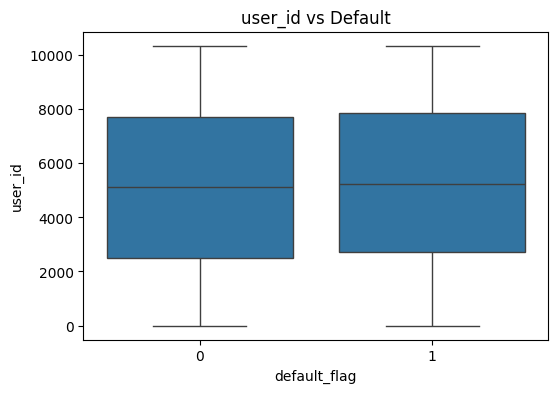

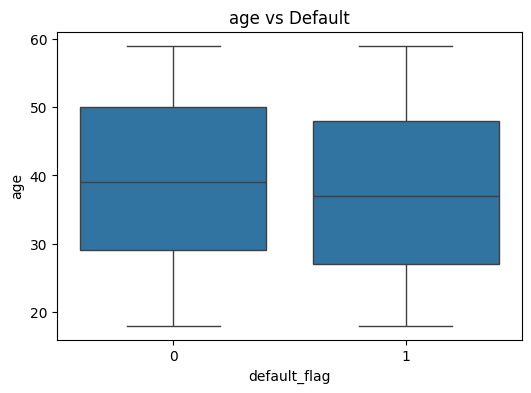

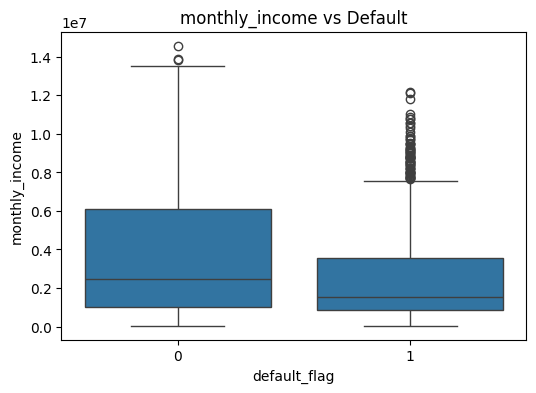

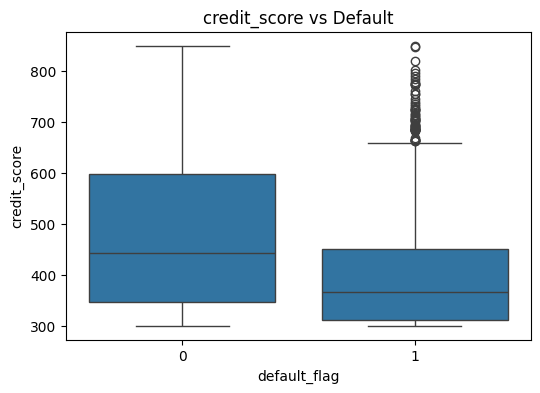

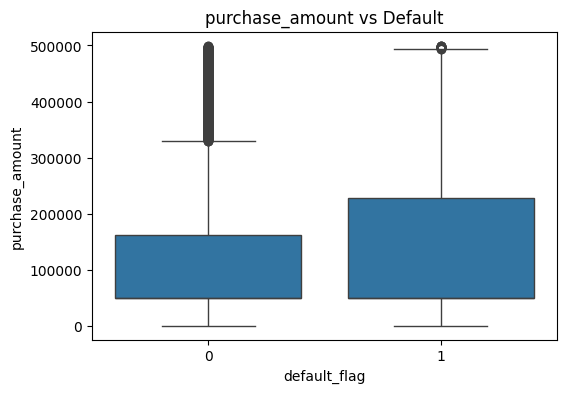

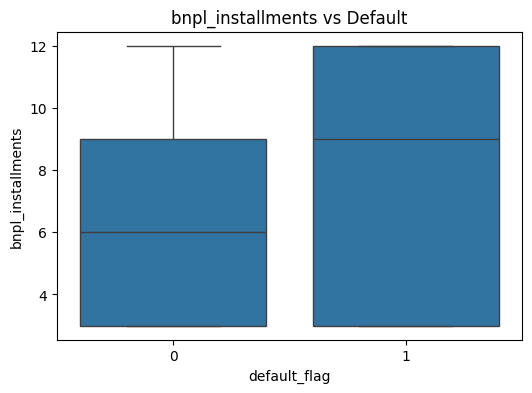

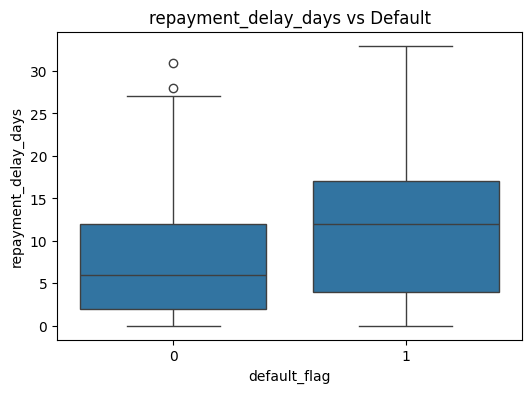

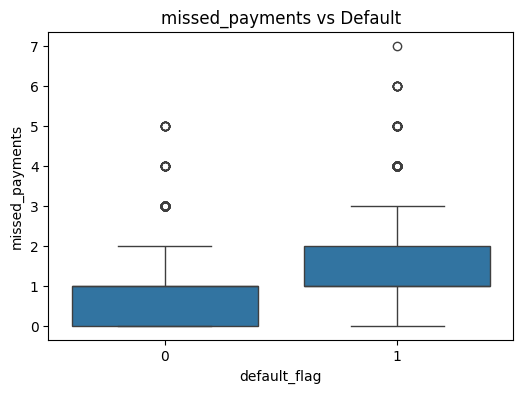

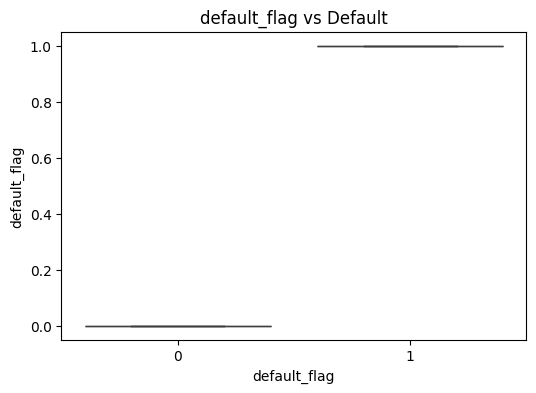

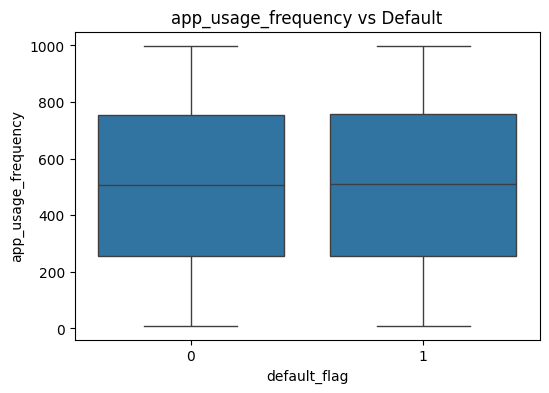

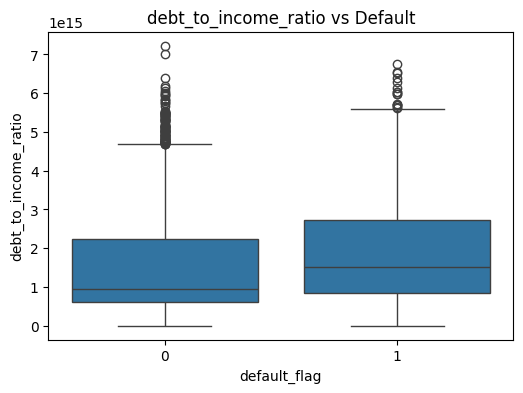

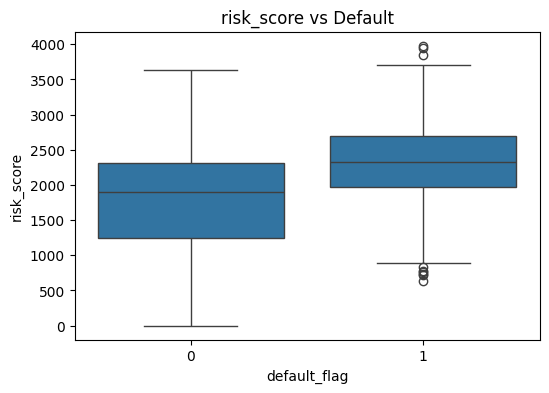

In [28]:
for col in variables_numericas_validas2:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='default_flag', y=col, data=df)
    plt.title(f"{col} vs Default")
    plt.show()

Variables como monthly_income, credit_score, bnpl_installments (?) y repayment_delay, son variables claves en la decisión
* Los clientes con mayor ingreso, tienden a no incumplir el pago
* Los clientes con mayor credit_score, normalmente no incumplen el pago
* A mayor número de cuotas es más probable que el cliente incumpla el pago
* Entre más se atrase en el pago un cliente, es más seguro que no cumpla con el pago del crédito definitivamente

#### Matriz de Correlación
Analizar redundancias entre variables

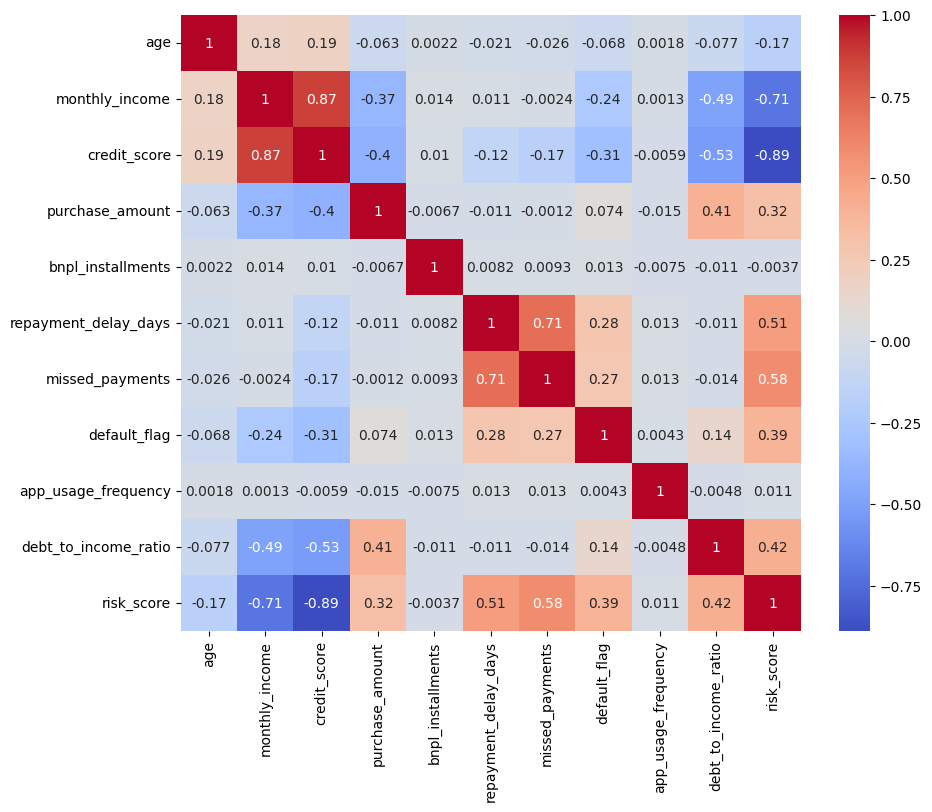

In [29]:
variables_numericas_validas2 = [
    col for col in variables_numericas_validas2 
    if col != 'user_id'
]

plt.figure(figsize=(10,8))
sns.heatmap(df[variables_numericas_validas2].corr(), annot=True, cmap='coolwarm')
plt.show()

In [30]:
corr_target = df.corr(numeric_only=True)['default_flag'].sort_values(ascending=False)
print(corr_target)

default_flag            1.000000
risk_score              0.391424
repayment_delay_days    0.279139
missed_payments         0.270351
debt_to_income_ratio    0.142078
purchase_amount         0.073973
user_id                 0.021340
bnpl_installments       0.013474
app_usage_frequency     0.004265
age                    -0.068212
monthly_income         -0.239924
credit_score           -0.312354
Name: default_flag, dtype: float64


De la matriz de correlación se puede concluir que:
* A mayor ingreso y mejor score crediticio, menor probabilidad hay de incumplimiento [monthly_income y credit_score]
* A mayor carga de deuda, mayor probabilidad de incumplimiento [debt_to_income]
* A mayor dias de retraso en los pagos e incumplimiento del pago de las cuotas, mayor posibilidad de incumplimiento [repayment_delay_days y missed_payments]

Así pues, podemos decir que monthly_income y credit_score tienen una relación inversamente proporcional con default_flag, m mientras que debt_to_income
 tienen una relación positiva con la variable objetivo, lo que fiinancieramente representa un riesgo crediticio.

## Clasificación de variables según lo analizado

### Cuantitativas:
Prioritarias:

* monthly_income
* credit_score
* debt_to_income
* repayment_delay_days
* missed_payments
* risk_score

Opcionales:
* bnpl_installments      
* app_usage_frequency     
* age                   
* purchase_amount       


### Categóricas:
Prioritarias:
* employment_type
* customer_segment

Opcionales:
* location 
* product_category


#### Mapa de calor con las variables numericas y categoricas

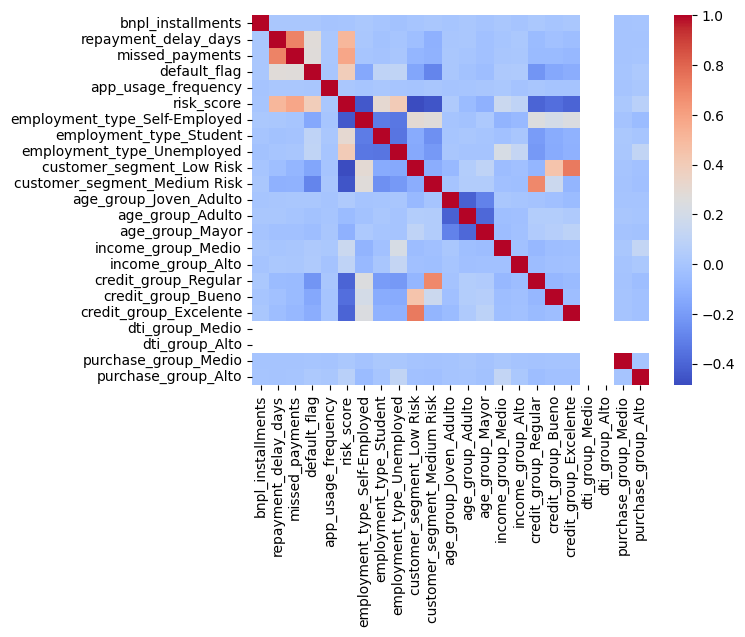

default_flag                     1.000000
risk_score                       0.391424
repayment_delay_days             0.279139
missed_payments                  0.270351
employment_type_Unemployed       0.109028
employment_type_Student          0.105868
income_group_Alto                0.032742
income_group_Medio               0.025910
purchase_group_Alto              0.023002
bnpl_installments                0.013474
age_group_Joven_Adulto           0.009289
app_usage_frequency              0.004265
purchase_group_Medio             0.001447
age_group_Adulto                -0.018422
age_group_Mayor                 -0.044184
credit_group_Excelente          -0.122247
credit_group_Bueno              -0.144640
employment_type_Self-Employed   -0.146947
customer_segment_Low Risk       -0.159950
credit_group_Regular            -0.229877
customer_segment_Medium Risk    -0.286437
dti_group_Medio                       NaN
dti_group_Alto                        NaN
Name: default_flag, dtype: float64

In [31]:
df_temp = feature_engineering(df)
sns.heatmap(df_temp.corr(), cmap='coolwarm')
plt.show()

corr = df_temp.corr()['default_flag'].sort_values(ascending=False)
print(corr)